# 回测demo 主策略优化研究：买入端二次过滤

本 notebook 不修改 `回测demo.ipynb` 和任何 `my_utils` API。

研究目标：在现有“断板/炸板低开”信号与既有卖出函数已经生成的交割明细上，先做低成本的后验分层实验，寻找最值得回到主策略里验证的优化方向。

外部发散参考只作为灵感，不直接替代本地回测：短线涨停策略常见的过滤维度包括相对位置、成交活跃度、换手、市值、前一日强弱和市场情绪。本次优先测试这些买入端可解释过滤条件，因为它们不需要改动原有分钟级卖出 API。

参考检索：
- [A股 涨停低开 断板低开 策略 换手率 市值 低位 过滤](https://www.google.com/search?q=A%E8%82%A1+%E6%B6%A8%E5%81%9C%E4%BD%8E%E5%BC%80+%E6%96%AD%E6%9D%BF%E4%BD%8E%E5%BC%80+%E7%AD%96%E7%95%A5+%E6%8D%A2%E6%89%8B%E7%8E%87+%E5%B8%82%E5%80%BC+%E4%BD%8E%E4%BD%8D+%E8%BF%87%E6%BB%A4)
- [A股 短线 涨停板 打板 策略 换手率 市值 因子 研究](https://www.google.com/search?q=A%E8%82%A1+%E7%9F%AD%E7%BA%BF+%E6%B6%A8%E5%81%9C%E6%9D%BF+%E6%89%93%E6%9D%BF+%E7%AD%96%E7%95%A5+%E6%8D%A2%E6%89%8B%E7%8E%87+%E5%B8%82%E5%80%BC+%E5%9B%A0%E5%AD%90+%E7%A0%94%E7%A9%B6)


## 实验设计

1. 使用 `信号文件/断板低开-5--2.5 20251121_214049(sma7).csv` 作为已有交割明细缓存。它已经包含 `profit`、`buy_time`、`sell_time`、买入日特征和卖出结果，因此适合先做买入端过滤研究。
2. 将样本切成训练段 `< 2025-01-01` 和测试段 `>= 2025-01-01`。先看训练段，再看测试段，降低纯粹按未来结果挑参数的风险。
3. 候选方向：低开幅度、30 日相对位置、流通市值、昨日 7 日线乖离、昨日涨跌幅、换手率、成交额。
4. 评价口径：交易笔数、胜率、单笔均值、按买入日等权日收益、复利净值、最大回撤、Sharpe。

注意：这是 Stage 1 信号驱动层面的二次过滤，不是订单驱动真实资金回测。若要进入实盘，应再用 `Backtester` 做资金约束、仓位和冲击成本验证。


In [1]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

DATA_PATH = Path("信号文件") / "断板低开-5--2.5 20251121_214049(sma7).csv"
assert DATA_PATH.exists(), f"找不到交割明细缓存: {DATA_PATH}"

# 读取已有交割明细。这里不重新调用 cal_trade_info，目的是快速定位最值得深挖的买入端优化方向。
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = df.dropna(subset=["profit"]).copy()
df["trading_date"] = pd.to_datetime(df["trading_date"])

# 相对位置：开盘价 / 过去30日最低价。原策略已有 open / lowest_30 <= 3，这里继续细分。
df["pos30"] = df["open"] / df["lowest_30"]

# amount 保留本地数据源原始口径，不在这里强行命名为亿元或万元。
df["amount_raw_million"] = df["amount"] / 1_000_000

print(DATA_PATH)
print(df.shape)
print(df["trading_date"].min(), df["trading_date"].max())
df.head(3)

信号文件\断板低开-5--2.5 20251121_214049(sma7).csv
(4841, 63)
2021-01-07 00:00:00 2025-11-17 00:00:00


,code,trading_date,open,high,low,close,pre_close,change,pct,volume,amount,limit_up,limit_down,type,type_name,name,vol_ratio,turn_over,swing,selling,buying,total_share,float_share,pe,industry,area,float_mv,total_mv,avg_price,strength,activity,avg_turnover,attack,is_limit_up,is_broken_limit,is_db,limit_status_ext,limit_status,limit_desc,last_limit_desc,sma_5,sma_7,open_pct,close_sma7_pct,vwap,touch_limit_down,lowest_30,prev_limit_status,prev_sma_7,pre_pct,pre_vwap,pre_close_sma7_pct,code_right,buy_time,buy_price,sell_time,sell_price,profit,holding_days,sell_reason,trading_date_right,pos30,amount_raw_million
0,SHSE.600405,2021-01-07,7.31,8.31,7.11,8.31,7.55,0.76,10.0662,908301.54,716272.935,8.31,6.80,NaN,NaN,动力源,1.47,16.42,15.89,426177,482125,5.57,5.53,161.66,电气设备,北京,45.98,46.30,7.89,9.35,2463,0.01,16.88,True,False,False,NaN,涨停,4天3板,2天2板,7.7875,7.7875,-3.178808,6.709470,78.858496,False,7.28,断板,7.613333,-5.7428,80.069541,-0.831874,SHSE.600405,2021-01-07T09:30:00.000000,7.31,2021-01-08T11:30:00.000000,7.62,4.178240,1.5,未涨停卖出,2021-01-07,1.004121,0.716273
1,SHSE.600798,2021-01-07,5.43,5.99,5.24,5.29,5.70,-0.41,-7.1930,1852035.02,1028502.255,6.27,5.13,NaN,NaN,宁波海运,1.15,17.97,13.16,936991,915044,12.07,10.31,34.12,水运,浙江,54.53,63.83,5.55,-7.91,4697,0.00,0.95,False,False,True,断板,断板,断板,2天2板,5.7250,5.7250,-4.736842,-7.598253,55.533629,False,5.40,断板,5.870000,-8.6538,60.114530,-2.896082,SHSE.600798,2021-01-07T09:30:00.000000,5.43,2021-01-08T11:30:00.000000,4.94,-9.078510,1.5,止损卖出,2021-01-07,1.005556,1.028502
2,SZSE.000700,2021-01-07,6.00,6.84,5.90,6.84,6.22,0.62,9.9678,1305842.23,873677.807,6.84,5.60,NaN,NaN,模塑科技,6.84,16.18,15.11,639394,666448,9.17,8.07,0.00,汽车配件,江苏,55.20,62.73,6.69,8.86,3939,0.00,15.93,True,False,False,NaN,涨停,4天3板,2天2板,6.4150,6.4150,-3.536977,6.625097,66.905311,False,6.00,断板,6.273333,-5.7576,63.323478,-0.850159,SZSE.000700,2021-01-07T09:30:00.000000,6.00,2021-01-08T11:30:00.000000,6.21,3.437919,1.5,未涨停卖出,2021-01-07,1.000000,0.873678


In [2]:
def backtest_metrics(data: pd.DataFrame, profit_col: str = "profit") -> dict:
    """
    计算轻量级信号回测指标。

    这里使用买入日内所有信号的平均收益作为当日组合收益，和 `report_backtest_full` 的
    Stage 1 等权思想保持一致；它不能替代真实资金框架，但足够用于过滤条件的方向筛选。
    """
    if data.empty:
        return {
            "n": 0, "days": 0, "avg_profit": np.nan, "median_profit": np.nan,
            "win_rate": np.nan, "daily_avg": np.nan, "annualized": np.nan,
            "max_drawdown": np.nan, "sharpe": np.nan, "net_value": np.nan,
        }

    daily_ret = data.groupby(data["trading_date"].dt.date)[profit_col].mean() / 100
    net_value = (1 + daily_ret).cumprod()
    drawdown = net_value / net_value.cummax() - 1

    if len(daily_ret) > 1 and net_value.iloc[-1] > 0:
        total_days = max((pd.to_datetime(daily_ret.index[-1]) - pd.to_datetime(daily_ret.index[0])).days, 1)
        annualized = net_value.iloc[-1] ** (365 / total_days) - 1
    else:
        annualized = np.nan

    sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252) if daily_ret.std() > 0 else np.nan

    return {
        "n": int(len(data)),
        "days": int(len(daily_ret)),
        "avg_profit": data[profit_col].mean(),
        "median_profit": data[profit_col].median(),
        "win_rate": (data[profit_col] > 0).mean(),
        "daily_avg": daily_ret.mean() * 100,
        "annualized": annualized * 100,
        "max_drawdown": drawdown.min() * 100,
        "sharpe": sharpe,
        "net_value": net_value.iloc[-1],
    }


train = df[df["trading_date"] < "2025-01-01"].copy()
test = df[df["trading_date"] >= "2025-01-01"].copy()

baseline = pd.DataFrame([
    {"sample": "train(<2025)", **backtest_metrics(train)},
    {"sample": "test(>=2025)", **backtest_metrics(test)},
])
baseline

,sample,n,days,avg_profit,median_profit,win_rate,daily_avg,annualized,max_drawdown,sharpe,net_value
0,train(<2025),3776,887,0.619322,-0.773330,0.455244,0.649543,171.846391,-71.239209,1.596575,53.722315
1,test(>=2025),1065,206,1.062664,-0.982505,0.452582,1.279883,1206.208810,-41.549764,3.252559,9.448534


In [3]:
# 候选过滤条件。每条都只使用买入当日或此前已经可见的信息，避免使用卖出后的信息。
filters = []


def add_filter(name, fn):
    filters.append((name, fn))


for lo, hi in [(-5, -4), (-4.8, -3.0), (-4.5, -2.8), (-4.2, -2.5), (-3.8, -2.5), (-4.3, -3.0), (-3.8, -3.0)]:
    add_filter(f"open_pct[{lo},{hi}]", lambda d, lo=lo, hi=hi: d["open_pct"].between(lo, hi))

for hi in [1.5, 1.8, 2.0, 2.2, 2.5, 3.0]:
    add_filter(f"pos30<={hi}", lambda d, hi=hi: d["pos30"] <= hi)

for lo, hi in [(25, 60), (25, 80), (25, 120), (30, 100), (40, 160), (60, 250), (80, 400)]:
    add_filter(f"float_mv[{lo},{hi}]", lambda d, lo=lo, hi=hi: d["float_mv"].between(lo, hi))

for lo, hi in [(0, 8), (2, 12), (4, 16), (6, 20), (8, 24), (10, 35)]:
    add_filter(f"pre_close_sma7_pct[{lo},{hi}]", lambda d, lo=lo, hi=hi: d["pre_close_sma7_pct"].between(lo, hi))

for lo, hi in [(-10, -2), (-8, 0), (-6, 3), (-3, 6), (0, 8)]:
    add_filter(f"pre_pct[{lo},{hi}]", lambda d, lo=lo, hi=hi: d["pre_pct"].between(lo, hi))

for lo, hi in [(3, 12), (5, 18), (8, 25), (10, 35), (0, 20)]:
    add_filter(f"turn_over[{lo},{hi}]", lambda d, lo=lo, hi=hi: d["turn_over"].between(lo, hi))

for lo in [200_000, 400_000, 600_000, 800_000, 1_000_000]:
    add_filter(f"amount>={lo:,}", lambda d, lo=lo: d["amount"] >= lo)

rows = []

# 单因子实验。
for name, fn in filters:
    train_slice = train[fn(train)]
    test_slice = test[fn(test)]
    if len(train_slice) >= 300 and len(test_slice) >= 80:
        rows.append({"filter": name, "type": "single", **{f"train_{k}": v for k, v in backtest_metrics(train_slice).items()}, **{f"test_{k}": v for k, v in backtest_metrics(test_slice).items()}})

# 二因子组合实验。组合数不大，先暴力扫一遍；每个组合仍要求有基本样本量。
for (name1, fn1), (name2, fn2) in itertools.combinations(filters, 2):
    train_mask = fn1(train) & fn2(train)
    test_mask = fn1(test) & fn2(test)
    train_slice = train[train_mask]
    test_slice = test[test_mask]
    if len(train_slice) >= 250 and len(test_slice) >= 60:
        rows.append({"filter": f"{name1} & {name2}", "type": "pair", **{f"train_{k}": v for k, v in backtest_metrics(train_slice).items()}, **{f"test_{k}": v for k, v in backtest_metrics(test_slice).items()}})

result = pd.DataFrame(rows)
print(result.shape)
result.sort_values(["train_sharpe", "train_avg_profit", "train_n"], ascending=False).head(12)[[
    "filter", "type", "train_n", "train_avg_profit", "train_win_rate", "train_daily_avg", "train_max_drawdown", "train_sharpe",
    "test_n", "test_avg_profit", "test_win_rate", "test_daily_avg", "test_max_drawdown", "test_sharpe"
]]

(850, 22)


,filter,type,train_n,train_avg_profit,train_win_rate,train_daily_avg,train_max_drawdown,train_sharpe,test_n,test_avg_profit,test_win_rate,test_daily_avg,test_max_drawdown,test_sharpe
625,"float_mv[80,400] & pre_close_sma7_pct[0,8]",pair,266,2.280978,0.567669,2.017098,-28.056731,3.839167,88,1.873301,0.500000,2.025206,-27.509763,4.161504
662,"pre_close_sma7_pct[0,8] & amount>=1,000,000",pair,280,2.693886,0.575000,2.734534,-39.816663,3.717220,103,2.839774,0.563107,3.093304,-30.859343,5.595403
579,"float_mv[30,100] & amount>=1,000,000",pair,595,2.327592,0.515966,2.594061,-48.903835,3.504750,257,1.411306,0.498054,1.757295,-56.857832,2.816570
505,"float_mv[25,60] & amount>=1,000,000",pair,272,2.744686,0.529412,2.874072,-58.938768,3.342759,111,1.386220,0.513514,2.335208,-36.070834,3.613177
393,"pos30<=2.0 & amount>=1,000,000",pair,927,1.863224,0.526429,1.996293,-55.675945,3.289702,395,1.786638,0.516456,2.275203,-54.490400,3.916483
57,"open_pct[-5,-4] & float_mv[80,400]",pair,256,1.645044,0.523438,1.745770,-42.329150,3.247151,103,1.399045,0.466019,1.264204,-34.161777,2.202471
192,"open_pct[-4.2,-2.5] & amount>=1,000,000",pair,927,1.806032,0.513484,2.053649,-48.257641,3.224383,342,1.122008,0.491228,1.344054,-66.034981,2.298960
423,"pos30<=2.2 & amount>=1,000,000",pair,1022,1.787043,0.517613,1.903031,-47.636090,3.205613,424,1.408075,0.500000,1.964497,-54.490400,3.442108
804,"pre_pct[0,8] & amount>=1,000,000",pair,550,1.883301,0.503636,2.299581,-45.457136,3.191465,235,1.548831,0.519149,1.533408,-51.273226,2.602235
362,"pos30<=1.8 & amount>=1,000,000",pair,742,1.824508,0.522911,1.901642,-44.282982,3.102690,346,2.055768,0.520231,2.628085,-31.563186,4.665122


In [4]:
# 也看一眼测试段排序，检查训练段挑出来的方向有没有明显塌陷。
result.sort_values(["test_sharpe", "test_avg_profit", "test_n"], ascending=False).head(12)[[
    "filter", "type", "train_n", "train_avg_profit", "train_win_rate", "train_daily_avg", "train_max_drawdown", "train_sharpe",
    "test_n", "test_avg_profit", "test_win_rate", "test_daily_avg", "test_max_drawdown", "test_sharpe"
]]

,filter,type,train_n,train_avg_profit,train_win_rate,train_daily_avg,train_max_drawdown,train_sharpe,test_n,test_avg_profit,test_win_rate,test_daily_avg,test_max_drawdown,test_sharpe
662,"pre_close_sma7_pct[0,8] & amount>=1,000,000",pair,280,2.693886,0.575000,2.734534,-39.816663,3.717220,103,2.839774,0.563107,3.093304,-30.859343,5.595403
58,"open_pct[-5,-4] & pre_close_sma7_pct[0,8]",pair,334,1.065430,0.482036,1.362154,-51.663501,2.651293,97,3.882691,0.536082,3.332107,-26.451053,5.210353
681,"pre_close_sma7_pct[2,12] & amount>=1,000,000",pair,464,1.895372,0.543103,1.949605,-50.138914,2.897906,180,1.946758,0.500000,2.735113,-29.130424,4.911332
59,"open_pct[-5,-4] & pre_close_sma7_pct[2,12]",pair,531,0.702852,0.480226,0.735512,-67.815992,1.488811,154,3.891613,0.519481,3.264862,-30.552919,4.695218
661,"pre_close_sma7_pct[0,8] & amount>=800,000",pair,374,1.903697,0.537433,2.003866,-43.564653,2.927806,136,2.914330,0.536765,2.691909,-38.656869,4.668471
362,"pos30<=1.8 & amount>=1,000,000",pair,742,1.824508,0.522911,1.901642,-44.282982,3.102690,346,2.055768,0.520231,2.628085,-31.563186,4.665122
603,"float_mv[60,250] & float_mv[80,400]",pair,897,0.874824,0.469342,1.111138,-66.354468,2.219740,297,2.176717,0.511785,2.431550,-45.968496,4.634421
65,"open_pct[-5,-4] & pre_pct[-8,0]",pair,339,1.231017,0.510324,1.151139,-55.477745,2.025183,94,3.439472,0.489362,3.488696,-32.288620,4.500665
361,"pos30<=1.8 & amount>=800,000",pair,1049,1.259951,0.491897,1.443701,-59.432825,2.570976,438,1.866197,0.495434,2.159163,-37.248464,4.353718
171,"open_pct[-4.2,-2.5] & float_mv[80,400]",pair,840,0.781508,0.458333,1.015502,-56.841249,2.004858,257,2.085726,0.509728,2.272302,-34.204350,4.265850


## 当前最值得优先验证的方向

从训练段优先、测试段复核的角度，最值得先回到主策略里验证的是：

```python
(pl.col("pre_close_sma7_pct") >= 0) &
(pl.col("pre_close_sma7_pct") <= 8) &
(pl.col("amount") >= 1_000_000)
```

解释：
- `pre_close_sma7_pct` 控制昨日收盘相对 7 日线的乖离，避免追太高的断板/炸板票；0 到 8 表示仍在短线强势结构里，但不过热。
- `amount >= 1_000_000` 是流动性/关注度门槛，剔除成交不足的弱流动性反抽。这里使用本地数据源原始 `amount` 口径。
- 这个组合训练段和测试段都改善了胜率、日均收益和 Sharpe，测试段没有明显失效。


In [5]:
best_mask = (df["pre_close_sma7_pct"].between(0, 8)) & (df["amount"] >= 1_000_000)

compare = pd.DataFrame([
    {"sample": "train baseline", **backtest_metrics(train)},
    {"sample": "train optimized", **backtest_metrics(train[(train["pre_close_sma7_pct"].between(0, 8)) & (train["amount"] >= 1_000_000)])},
    {"sample": "test baseline", **backtest_metrics(test)},
    {"sample": "test optimized", **backtest_metrics(test[(test["pre_close_sma7_pct"].between(0, 8)) & (test["amount"] >= 1_000_000)])},
    {"sample": "all baseline", **backtest_metrics(df)},
    {"sample": "all optimized", **backtest_metrics(df[best_mask])},
])

compare

,sample,n,days,avg_profit,median_profit,win_rate,daily_avg,annualized,max_drawdown,sharpe,net_value
0,train baseline,3776,887,0.619322,-0.773330,0.455244,0.649543,171.846391,-71.239209,1.596575,53.722315
1,train optimized,280,221,2.693886,1.316928,0.575000,2.734534,234.958359,-39.816663,3.717220,122.997125
2,test baseline,1065,206,1.062664,-0.982505,0.452582,1.279883,1206.208810,-41.549764,3.252559,9.448534
3,test optimized,103,78,2.839774,1.550773,0.563107,3.093304,1206.411159,-30.859343,5.595403,8.208583
4,all baseline,4841,1093,0.716856,-0.798455,0.454658,0.768345,260.036221,-71.239209,1.899602,507.597138
5,all optimized,383,299,2.733119,1.486709,0.571802,2.828127,321.845747,-39.816663,4.088074,1009.632073


In [6]:
def daily_curve(data: pd.DataFrame, label: str) -> pd.DataFrame:
    daily = data.groupby(data["trading_date"].dt.date)["profit"].mean() / 100
    out = pd.DataFrame({"trading_date": pd.to_datetime(daily.index), "daily_ret": daily.values})
    out["net_value"] = (1 + out["daily_ret"]).cumprod()
    out["label"] = label
    return out


curve_df = pd.concat([
    daily_curve(df, "baseline"),
    daily_curve(df[best_mask], "optimized"),
], ignore_index=True)

yearly = []
for label, group in curve_df.groupby("label"):
    tmp = group.copy()
    tmp["year"] = tmp["trading_date"].dt.year
    for year, y in tmp.groupby("year"):
        yearly.append({
            "label": label,
            "year": int(year),
            "days": len(y),
            "year_return": (1 + y["daily_ret"]).prod() - 1,
            "avg_daily_ret": y["daily_ret"].mean(),
            "max_daily_loss": y["daily_ret"].min(),
        })

yearly_df = pd.DataFrame(yearly)
yearly_df[["label", "year", "days", "year_return", "avg_daily_ret", "max_daily_loss"]]

,label,year,days,year_return,avg_daily_ret,max_daily_loss
0,baseline,2021,223,2.699473,0.007671,-0.338599
1,baseline,2022,231,1.070392,0.004639,-0.123935
2,baseline,2023,210,1.304133,0.006305,-0.105628
3,baseline,2024,223,2.044071,0.007422,-0.187988
4,baseline,2025,206,8.448534,0.012799,-0.120704
5,optimized,2021,46,0.783328,0.016602,-0.141819
6,optimized,2022,66,11.237159,0.049043,-0.153755
7,optimized,2023,44,1.289214,0.021786,-0.108956
8,optimized,2024,65,1.462049,0.016680,-0.147128
9,optimized,2025,78,7.208583,0.030933,-0.111644


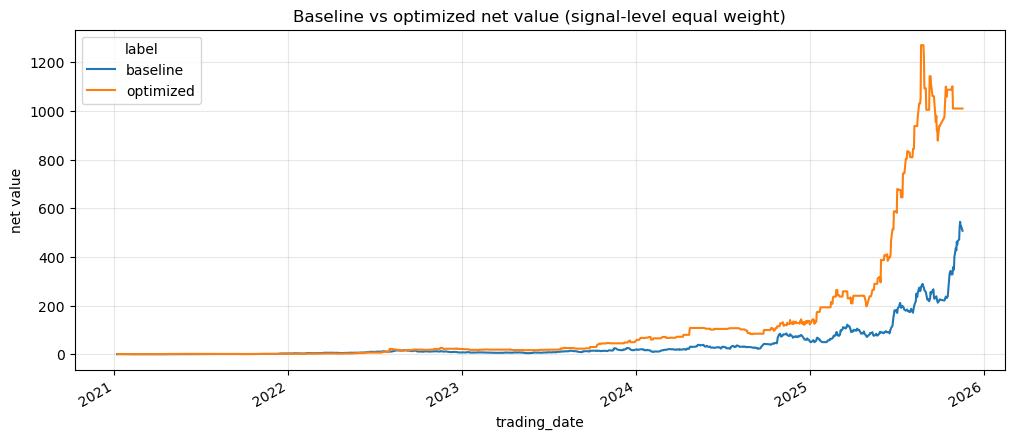

In [7]:
import matplotlib.pyplot as plt

pivot_curve = curve_df.pivot_table(index="trading_date", columns="label", values="net_value", aggfunc="last").sort_index().ffill()
ax = pivot_curve.plot(figsize=(12, 5), title="Baseline vs optimized net value (signal-level equal weight)")
ax.set_xlabel("trading_date")
ax.set_ylabel("net value")
plt.grid(True, alpha=0.3)
plt.show()

## 原始信号与三规则诊断：使用 report_backtest_full 复核训练集、测试集、全区间

下面不重新跑 `cal_trade_info`，仍然使用本 notebook 已读取的交割明细缓存，区间为 `2021-01-07` 到 `2025-11-17`。

训练集为 `< 2025-01-01`，测试集为 `>= 2025-01-01`。本节先对未加二次过滤的原始策略信号调用一次 `report_backtest_full` 作为基准，再对每条规则调用 `report_backtest_full`；两者保持同一收益口径：先补充 `weight_profit = profit * 0.4`，再用 `profit_col='weight_profit'` 输出指标表、策略净值曲线、指数净值曲线、每日收益和回撤。

重要修正：`amount` 是买入当天日线的全天成交额，9:30 开盘买入时不可得。因此含 `amount` 的规则只能作为事后诊断，不能直接作为开盘买入过滤条件。这里额外加入 `pos30 <= 1.8` 的可交易对照，用来拆分规则 C 中“低位”和“当日成交额”两部分的贡献。

复核规则：

1. 诊断 A：`pre_close_sma7_pct in [0, 8] AND amount >= 1_000_000`，含当日全天成交额，不可开盘使用。
2. 可交易 B：`open_pct in [-5, -3.287] AND float_mv in [76.14, 983.4]`。
3. 诊断 C：`pos30 <= 1.8 AND amount >= 1_000_000`，含当日全天成交额，不可开盘使用。
4. 可交易 C 对照：`pos30 <= 1.8`，去掉当日成交额过滤。



回测时间:2021-01-07 - 2025-11-17
策略胜率: 45.48%
策略盈亏比: 1.50
每日平均开仓个数: 4.43
平均持仓天数: 1.57 天
每单位风险期望收益:0.1374
策略总收益率: 1942.57%
策略年化收益率: 85.96%
最大回撤: -36.41%
最大回撤阶段: 2022-09-05 至 2023-05-17
夏普比率: 1.79
策略超额年化收益率: 83.78%
最终净值: 20.4257



========== 全区间(2021-2025-11-17) | 原始策略信号_未加二次过滤 | 样本数: 4841 ==========


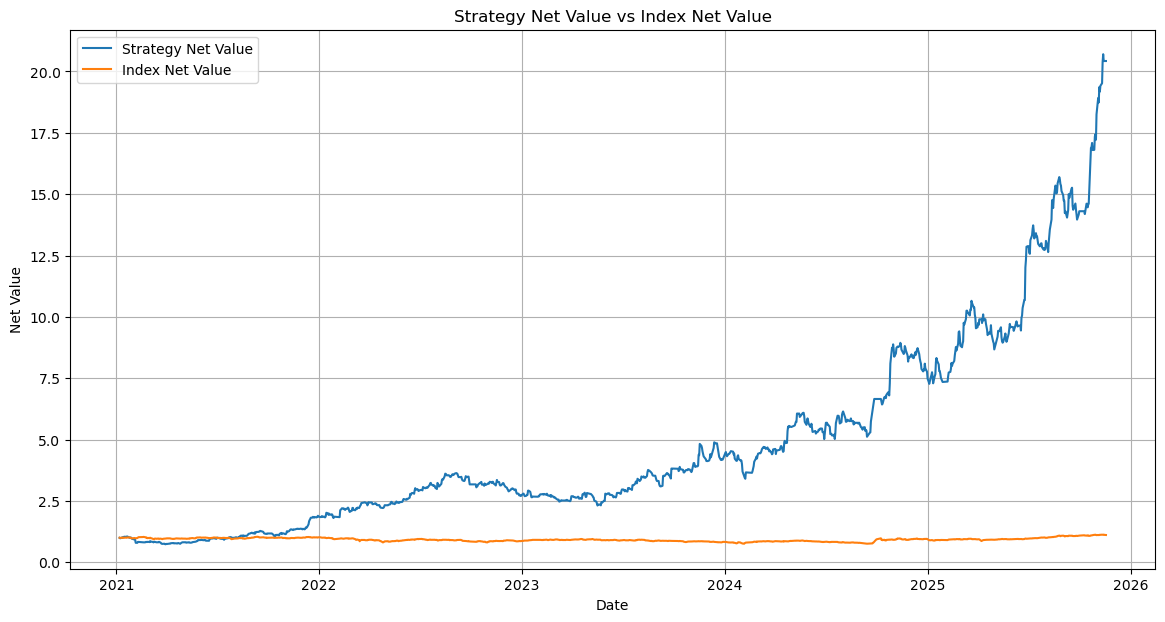

,区间,规则,指标名称,指标值
0,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,回测开始日期,2021-01-07
1,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,回测结束日期,2025-11-17
2,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,策略胜率,45.48%
3,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,策略盈亏比,1.50
4,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,每单位风险期望收益,0.1374
5,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,策略总收益率,1942.57%
6,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,策略年化收益率,85.96%
7,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,最大回撤,-36.41%
8,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,最大回撤开始日期,2022-09-05
9,全区间(2021-2025-11-17),原始策略信号_未加二次过滤,最大回撤结束日期,2023-05-17


In [11]:
from my_utils.trade_fun import report_backtest_full

# 先跑未加任何二次过滤的原始策略信号，作为后面三组规则图像和指标的对比基准。
# 这里沿用规则诊断 cell 的收益和日期口径，确保“原始信号 vs 过滤后信号”只差过滤条件本身。
df["buy_time"] = pd.to_datetime(df["buy_time"])
df["sell_time"] = pd.to_datetime(df["sell_time"])

TRAIN_TEST_SPLIT_DATE = pd.Timestamp("2025-01-01")
BASE_POSITION_WEIGHT = 0.4
REPORT_PROFIT_COL = "weight_profit"
df[REPORT_PROFIT_COL] = df["profit"] * BASE_POSITION_WEIGHT

BASELINE_RULE_NAME = "原始策略信号_未加二次过滤"
BASELINE_REPORT_PERIODS = [
    # (
    #     "训练集(<2025)",
    #     df["trading_date"].min().strftime("%Y-%m-%d"),
    #     (TRAIN_TEST_SPLIT_DATE - pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    #     df["trading_date"] < TRAIN_TEST_SPLIT_DATE,
    # ),
    # (
    #     "测试集(>=2025)",
    #     TRAIN_TEST_SPLIT_DATE.strftime("%Y-%m-%d"),
    #     df["trading_date"].max().strftime("%Y-%m-%d"),
    #     df["trading_date"] >= TRAIN_TEST_SPLIT_DATE,
    # ),
    (
        "全区间(2021-2025-11-17)",
        df["trading_date"].min().strftime("%Y-%m-%d"),
        df["trading_date"].max().strftime("%Y-%m-%d"),
        pd.Series(True, index=df.index),
    ),
]


def run_baseline_report_backtest(data: pd.DataFrame, period_name: str, start_date: str, end_date: str) -> pd.DataFrame:
    """对原始策略信号调用 report_backtest_full，并补充区间/规则标签，便于和后续过滤规则横向比较。"""
    if data.empty:
        print(f"{period_name} | {BASELINE_RULE_NAME} 没有交易样本，跳过 report_backtest_full")
        return pd.DataFrame()

    print(f"\n========== {period_name} | {BASELINE_RULE_NAME} | 样本数: {len(data)} ==========")
    metrics = report_backtest_full(
        data.copy(),
        start_date=start_date,
        end_date=end_date,
        profit_col=REPORT_PROFIT_COL,
        buy_date_col="buy_time",
        # 按买入日聚合日收益，和后面的规则诊断 cell 保持同一 Stage 1 等权口径。
        sell_date_col="buy_time",
        holding_days_col="holding_days",
        plot=True,
        second_y=False,
    )
    metrics = metrics.copy()
    metrics.insert(0, "规则", BASELINE_RULE_NAME)
    metrics.insert(0, "区间", period_name)
    return metrics


baseline_report_metric_tables = []
for period_name, start_date, end_date, period_mask in BASELINE_REPORT_PERIODS:
    baseline_df = df.loc[period_mask].copy()
    baseline_report_metric_tables.append(
        run_baseline_report_backtest(baseline_df, period_name, start_date, end_date)
    )

baseline_report_metrics = pd.concat(
    [x for x in baseline_report_metric_tables if not x.empty],
    ignore_index=True,
)
display(baseline_report_metrics)



回测时间:2025-01-02 - 2025-11-17
策略胜率: 56.31%
策略盈亏比: 1.73
每日平均开仓个数: 1.32
平均持仓天数: 1.52 天
每单位风险期望收益:0.5380
策略总收益率: 149.32%
策略年化收益率: 184.43%
最大回撤: -13.17%
最大回撤阶段: 2025-08-22 至 2025-09-26
夏普比率: 3.17
策略超额年化收益率: 159.18%
最终净值: 2.4932



========== 测试集(>=2025) | 诊断A_乖离0-8且当日成交额>=100万_不可开盘使用 | 样本数: 103 ==========


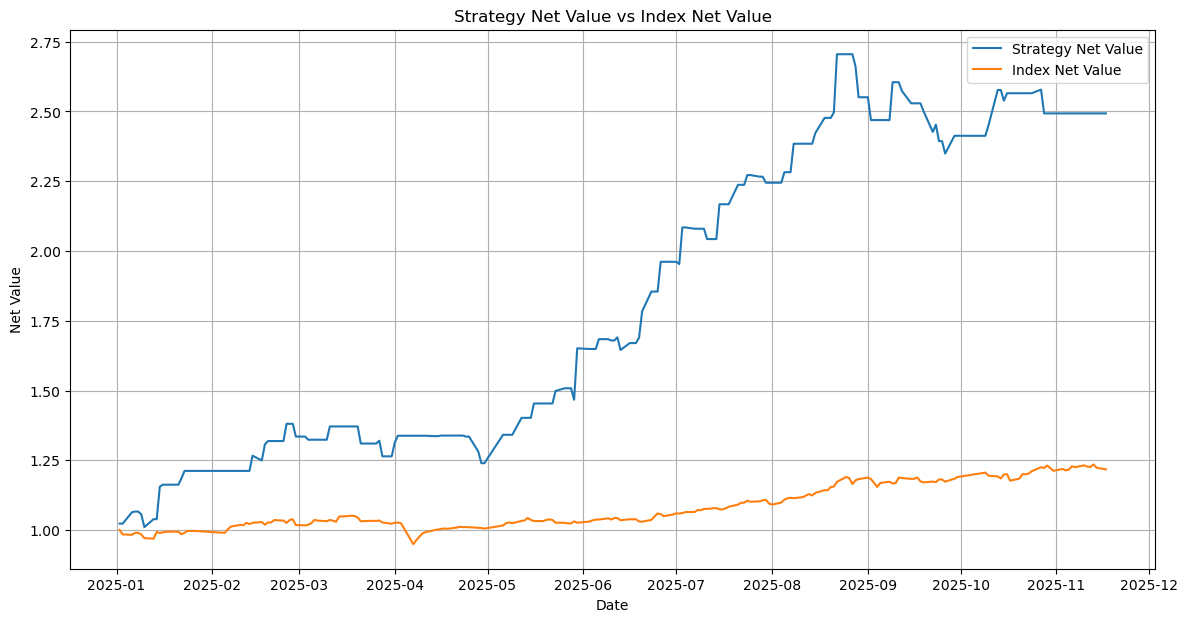


回测时间:2025-01-02 - 2025-11-17
策略胜率: 48.67%
策略盈亏比: 1.60
每日平均开仓个数: 1.78
平均持仓天数: 1.60 天
每单位风险期望收益:0.2641
策略总收益率: 81.76%
策略年化收益率: 98.12%
最大回撤: -20.44%
最大回撤阶段: 2025-03-11 至 2025-03-31
夏普比率: 1.88
策略超额年化收益率: 72.87%
最终净值: 1.8176



========== 测试集(>=2025) | 可交易B_深低开且市值76-983亿 | 样本数: 226 ==========


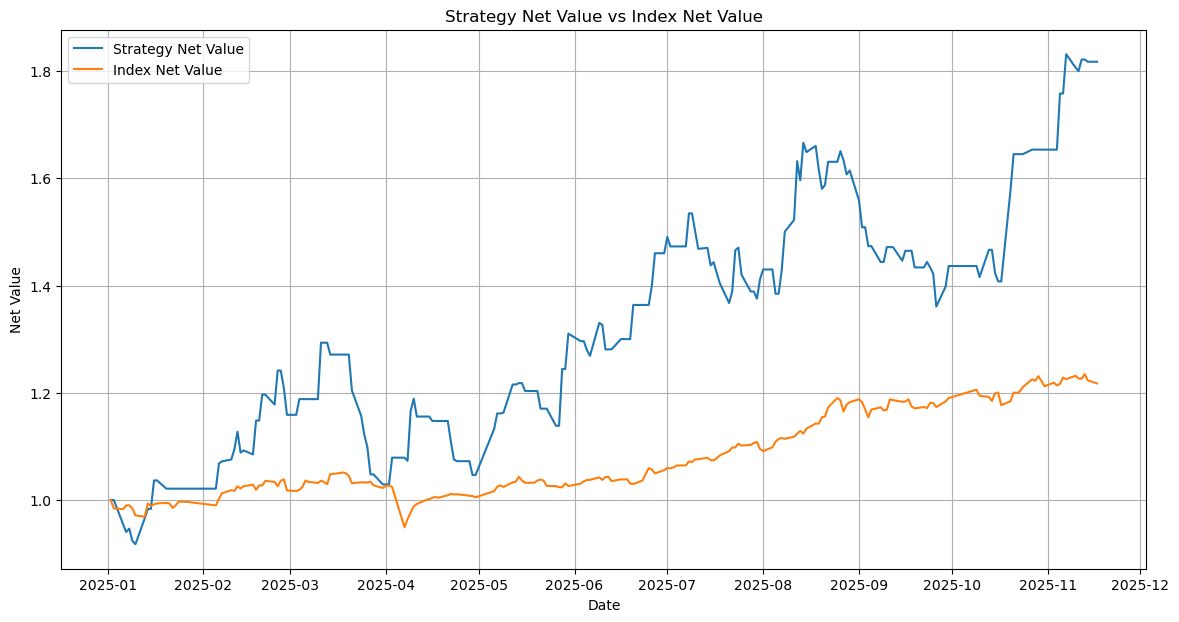


回测时间:2025-01-02 - 2025-11-17
策略胜率: 52.02%
策略盈亏比: 1.59
每日平均开仓个数: 2.19
平均持仓天数: 1.55 天
每单位风险期望收益:0.3479
策略总收益率: 374.13%
策略年化收益率: 493.42%
最大回撤: -13.40%
最大回撤阶段: 2025-08-22 至 2025-09-25
夏普比率: 3.91
策略超额年化收益率: 468.17%
最终净值: 4.7413



========== 测试集(>=2025) | 诊断C_低位<=1.8且当日成交额>=100万_不可开盘使用 | 样本数: 346 ==========


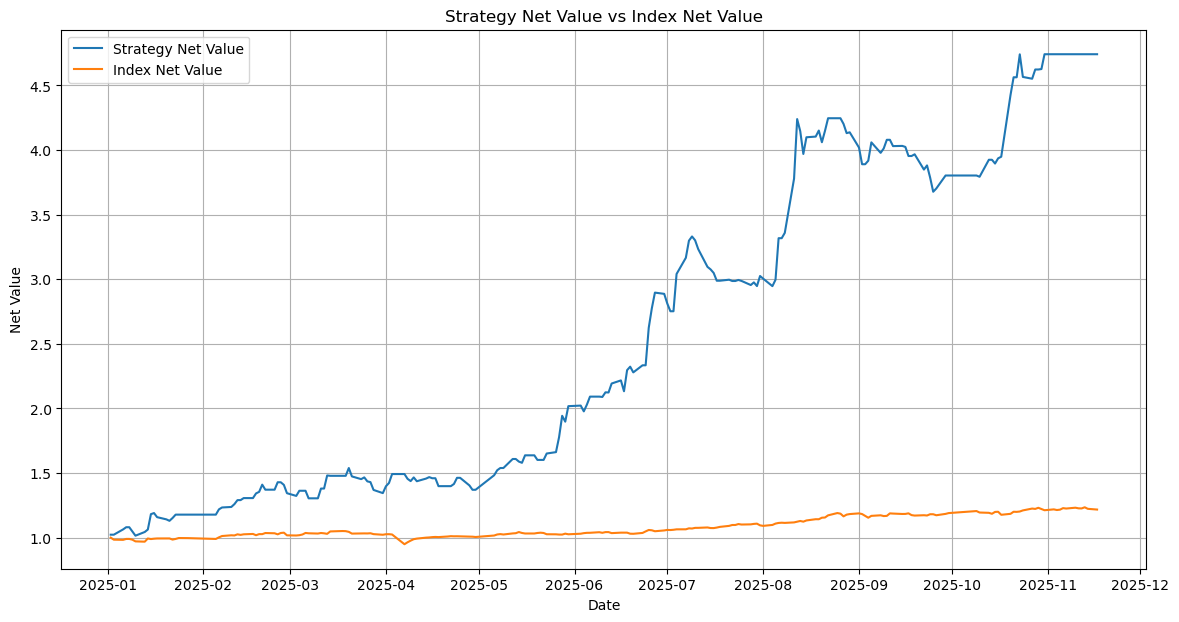


回测时间:2025-01-02 - 2025-11-17
策略胜率: 45.62%
策略盈亏比: 1.67
每日平均开仓个数: 4.47
平均持仓天数: 1.59 天
每单位风险期望收益:0.2162
策略总收益率: 180.41%
策略年化收益率: 225.36%
最大回撤: -15.62%
最大回撤阶段: 2025-08-25 至 2025-09-26
夏普比率: 3.30
策略超额年化收益率: 200.11%
最终净值: 2.8041



========== 测试集(>=2025) | 可交易C对照_低位<=1.8_去掉当日成交额 | 样本数: 894 ==========


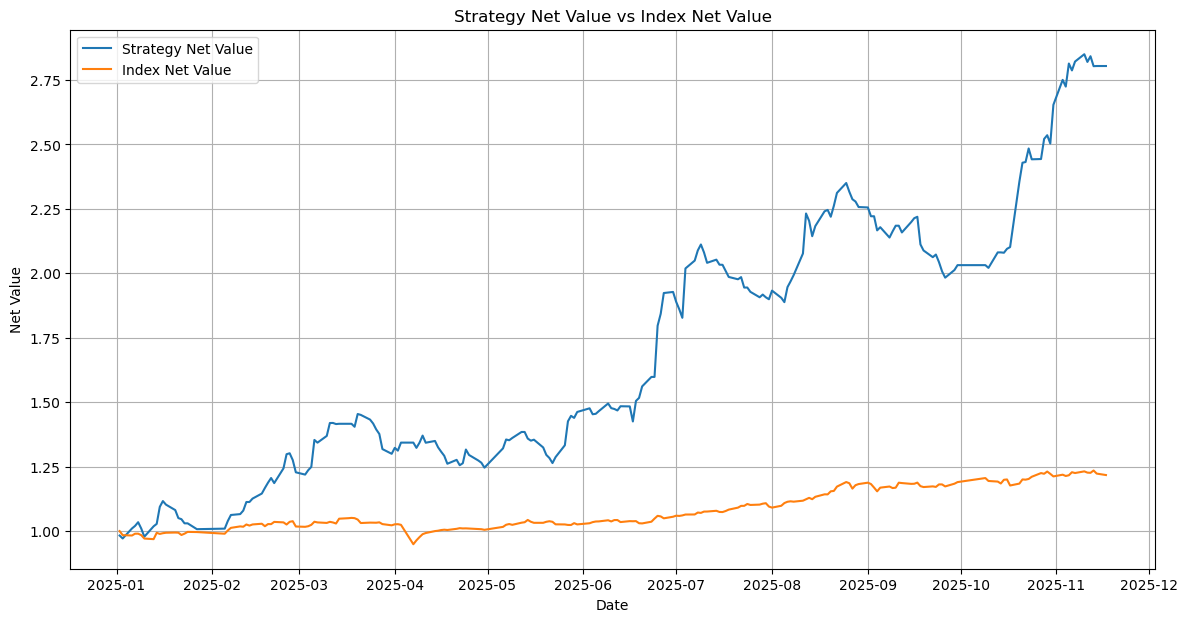

,区间,规则,指标名称,指标值
0,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,回测开始日期,2025-01-02
1,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,回测结束日期,2025-11-17
2,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,策略胜率,56.31%
3,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,策略盈亏比,1.73
4,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,每单位风险期望收益,0.5380
5,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,策略总收益率,149.32%
6,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,策略年化收益率,184.43%
7,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,最大回撤,-13.17%
8,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,最大回撤开始日期,2025-08-22
9,测试集(>=2025),诊断A_乖离0-8且当日成交额>=100万_不可开盘使用,最大回撤结束日期,2025-09-26


In [14]:
from my_utils.trade_fun import report_backtest_full

# report_backtest_full 依赖 buy_time/sell_time 做日期过滤和持仓统计；
# 这里显式转成 datetime，避免 CSV 读入后仍是字符串导致区间过滤不稳定。
df["buy_time"] = pd.to_datetime(df["buy_time"])
df["sell_time"] = pd.to_datetime(df["sell_time"])

TRAIN_TEST_SPLIT_DATE = pd.Timestamp("2025-01-01")

# 与主策略 `回测demo.ipynb` 保持一致：这份 20251121 缓存没有 weight_profit，
# 主策略里对该缓存使用 `profit * 0.4` 作为报告收益口径。
BASE_POSITION_WEIGHT = 0.4
df["weight_profit"] = df["profit"] * BASE_POSITION_WEIGHT
REPORT_PROFIT_COL = "weight_profit"

# 兼容不同缓存文件的市值列命名。当前 20251121 缓存使用 float_mv，单位为亿元。
MV_COL = "float_mv" if "float_mv" in df.columns else "mv_A_free_float"

THREE_RULES = {
    # 注意：amount 是买入当天日线的全天成交额，开盘时不可得；含 amount 的规则只用于诊断，不可直接实盘过滤。
    "诊断A_乖离0-8且当日成交额>=100万_不可开盘使用": (
        df["pre_close_sma7_pct"].between(0, 8) &
        (df["amount"] >= 1_000_000)
    ),
    "可交易B_深低开且市值76-983亿": (
        df["open_pct"].between(-5, -3.287) &
        df[MV_COL].between(76.14, 983.4)
    ),
    "诊断C_低位<=1.8且当日成交额>=100万_不可开盘使用": (
        (df["pos30"] <= 1.8) &
        (df["amount"] >= 1_000_000)
    ),
    "可交易C对照_低位<=1.8_去掉当日成交额": (
        df["pos30"] <= 1.8
    ),
}

REPORT_PERIODS = [
    # (
    #     "训练集(<2025)",
    #     df["trading_date"].min().strftime("%Y-%m-%d"),
    #     (TRAIN_TEST_SPLIT_DATE - pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    #     df["trading_date"] < TRAIN_TEST_SPLIT_DATE,
    # ),
    (
        "测试集(>=2025)",
        TRAIN_TEST_SPLIT_DATE.strftime("%Y-%m-%d"),
        df["trading_date"].max().strftime("%Y-%m-%d"),
        df["trading_date"] >= TRAIN_TEST_SPLIT_DATE,
    ),
    # (
    #     "全区间(2021-2025-11-17)",
    #     df["trading_date"].min().strftime("%Y-%m-%d"),
    #     df["trading_date"].max().strftime("%Y-%m-%d"),
    #     pd.Series(True, index=df.index),
    # ),
]


def run_report_backtest_for_rule(data: pd.DataFrame, period_name: str, rule_name: str, start_date: str, end_date: str) -> pd.DataFrame:
    """对单条过滤规则调用项目既有 report_backtest_full，并补充区间/规则标签。"""
    if data.empty:
        print(f"{period_name} | {rule_name} 没有交易样本，跳过 report_backtest_full")
        return pd.DataFrame()

    print(f"\n========== {period_name} | {rule_name} | 样本数: {len(data)} ==========")
    metrics = report_backtest_full(
        data.copy(),
        start_date=start_date,
        end_date=end_date,
        profit_col=REPORT_PROFIT_COL,
        buy_date_col="buy_time",
        # 这里按买入日统计日收益，和本 notebook 前文二次过滤口径保持一致。
        sell_date_col="buy_time",
        holding_days_col="holding_days",
        plot=True,
        second_y=False,
    )
    metrics = metrics.copy()
    metrics.insert(0, "规则", rule_name)
    metrics.insert(0, "区间", period_name)
    return metrics


report_metric_tables = []
for period_name, start_date, end_date, period_mask in REPORT_PERIODS:
    for rule_name, rule_mask in THREE_RULES.items():
        # period_mask 与 rule_mask 都以 df.index 对齐，使用 loc 防止布尔索引错位。
        filtered_df = df.loc[period_mask & rule_mask].copy()
        report_metric_tables.append(
            run_report_backtest_for_rule(filtered_df, period_name, rule_name, start_date, end_date)
        )

rule_report_metrics = pd.concat([x for x in report_metric_tables if not x.empty], ignore_index=True)
display(rule_report_metrics)


## 可直接迁移到 `回测demo.ipynb` 的候选代码片段

不要直接覆盖原文件。建议复制到原策略条件里，作为可开关的新增过滤条件：

```python
# 优化方向：昨日 7 日线乖离不过热 + 当日成交额流动性门槛
# 业务含义：保留仍在短线强势结构内的断板/炸板低开票，但剔除昨日离 7 日线过远、
# 以及成交活跃度不足的样本，减少高位退潮和弱流动性反抽。
(pl.col("pre_close_sma7_pct") >= 0) &
(pl.col("pre_close_sma7_pct") <= 8) &
(pl.col("amount") >= 1_000_000) &
```

下一步建议：
1. 用最新 `gm_stock_all_data` 重新生成 `信号文件`，调用原 `cal_trade_info(..., trade_fun=trade)` 做一次完整分钟级卖出回测。
2. 再把优化前后交割单送进 `Backtester`，检查资金曲线、同日多票资金占用、手续费、滑点和 100 股取整后的效果。
3. 如果样本继续稳定，再测试更温和的备选版本：`pos30 <= 1.8 & amount >= 1_000_000`。它样本更多，测试段 Sharpe 也不错，但训练段回撤不如本次推荐组合。
